# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [40]:
base = pd.read_csv("/content/CARDIO_BASE.csv", delimiter=';')

In [41]:
# Visualizando as primeiras linhas
display(base.head())


,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62,1,1,0,0,1,0
1,55,1,156,85,3,1,0,0,1,1
2,52,1,165,64,3,1,0,0,0,1
3,48,2,169,82,1,1,0,0,1,1
4,48,1,156,56,1,1,0,0,0,0


In [42]:
# Informações gerais da base
print(base.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB
None


In [43]:
# Verificando tipos de dados
print(base.dtypes)

age                int64
gender             int64
height             int64
weight            object
cholesterol        int64
gluc               int64
smoke              int64
alco               int64
active             int64
cardio_disease     int64
dtype: object


In [44]:
# Converter weight para numérico

base['weight'] = base['weight'].astype(str)  # garante que seja string

# Caso existam vírgulas, troca por ponto
base['weight'] = base['weight'].str.replace(',', '.')

# Converter para número
base['weight'] = pd.to_numeric(base['weight'])

# Verificar novamente os tipos
print(base.dtypes)

age                 int64
gender              int64
height              int64
weight            float64
cholesterol         int64
gluc                int64
smoke               int64
alco                int64
active              int64
cardio_disease      int64
dtype: object


In [45]:
# Verificando valores faltantes
print(base.isnull().sum())

age               0
gender            0
height            0
weight            0
cholesterol       0
gluc              0
smoke             0
alco              0
active            0
cardio_disease    0
dtype: int64


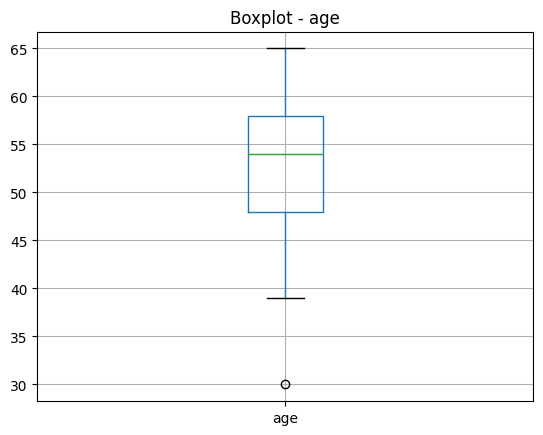

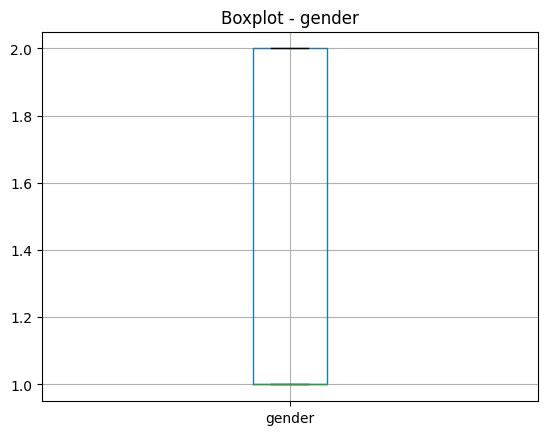

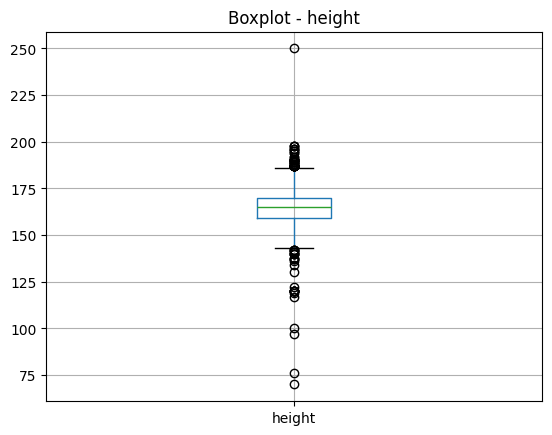

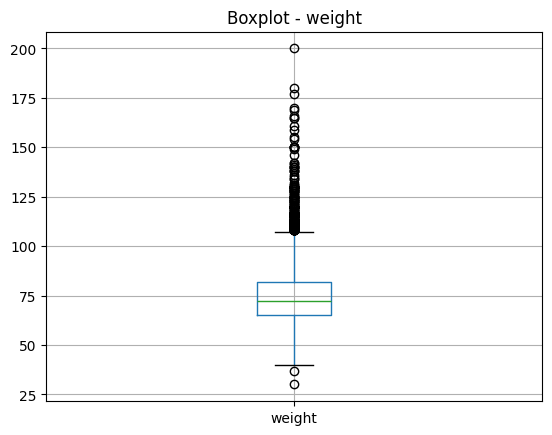

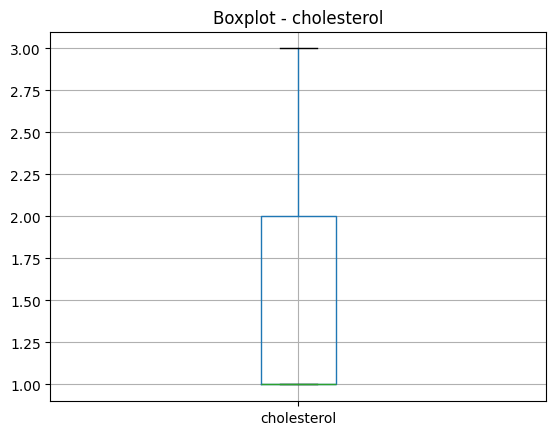

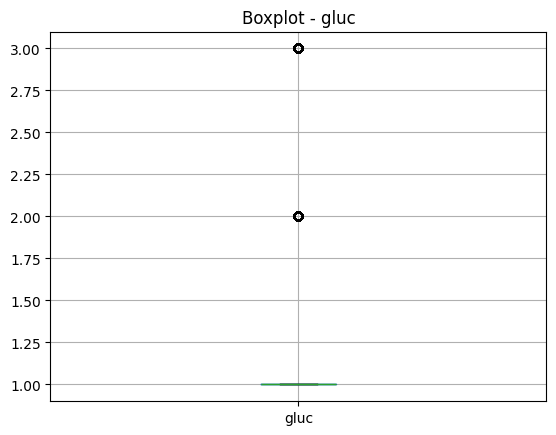

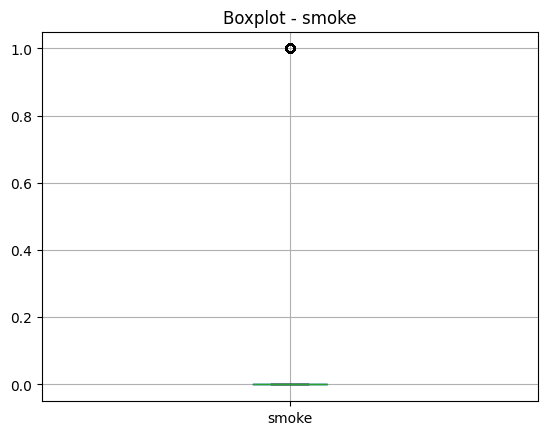

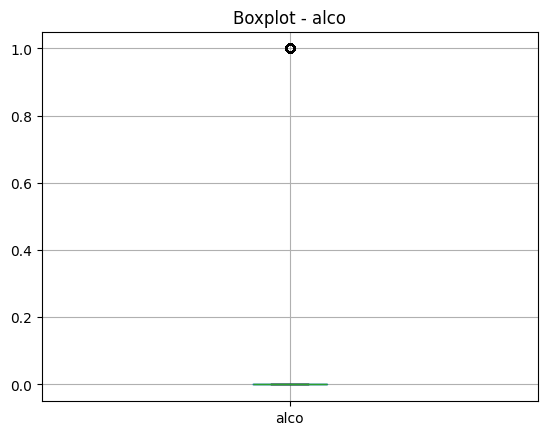

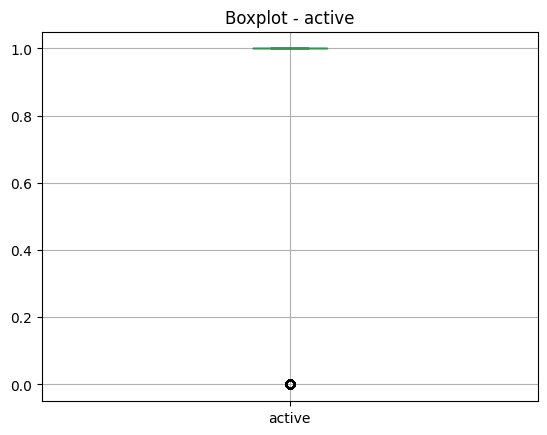

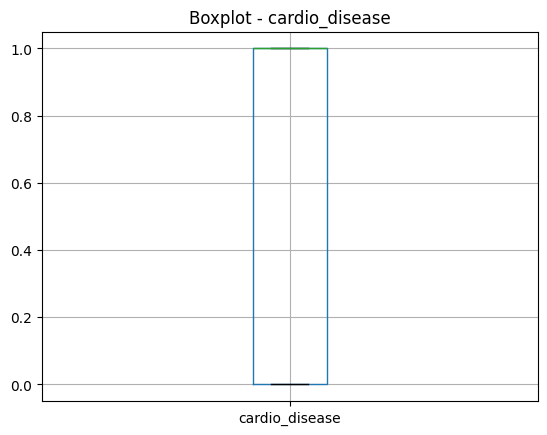

In [46]:
# Selecionando colunas numéricas
colunas_numericas = base.select_dtypes(include=['int64', 'float64']).columns

# Criando boxplots
for col in colunas_numericas:
    plt.figure()
    base.boxplot(column=col)
    plt.title(f'Boxplot - {col}')
    plt.show()

In [47]:
# Selecionar colunas numéricas
colunas_numericas = base.select_dtypes(include=['int64', 'float64']).columns

# Função para detectar outliers
def contar_outliers(df, coluna):

    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ]

    return len(outliers)

# Contando outliers por coluna
for col in colunas_numericas:
    quantidade = contar_outliers(base, col)
    print(f"{col}: {quantidade} outliers")

age: 1 outliers
gender: 0 outliers
height: 74 outliers
weight: 247 outliers
cholesterol: 0 outliers
gluc: 1487 outliers
smoke: 890 outliers
alco: 537 outliers
active: 2028 outliers
cardio_disease: 0 outliers


In [48]:
import numpy as np

colunas_tratar = ['age', 'height', 'weight']

for col in colunas_tratar:

    Q1 = base[col].quantile(0.25)
    Q3 = base[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    base[col] = np.where(base[col] < limite_inferior,
                         limite_inferior,
                         base[col])

    base[col] = np.where(base[col] > limite_superior,
                         limite_superior,
                         base[col])

print("Outliers tratados nas colunas numéricas contínuas.")

Outliers tratados nas colunas numéricas contínuas.


# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


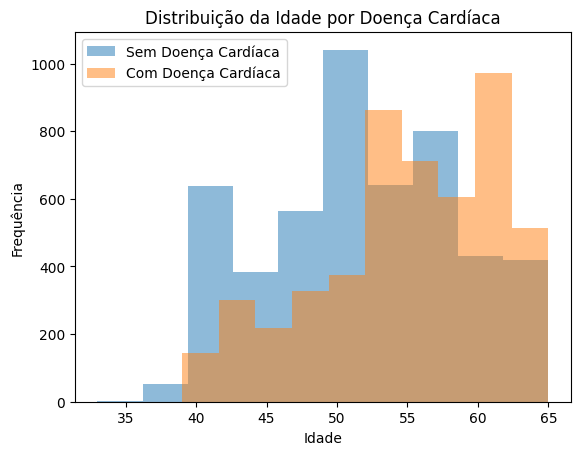

In [49]:
import matplotlib.pyplot as plt

# Separando grupos
cardio_0 = base[base['cardio_disease'] == 0]
cardio_1 = base[base['cardio_disease'] == 1]

plt.figure()

plt.hist(cardio_0['age'], alpha=0.5, label='Sem Doença Cardíaca')
plt.hist(cardio_1['age'], alpha=0.5, label='Com Doença Cardíaca')

plt.title('Distribuição da Idade por Doença Cardíaca')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.legend()

plt.show()

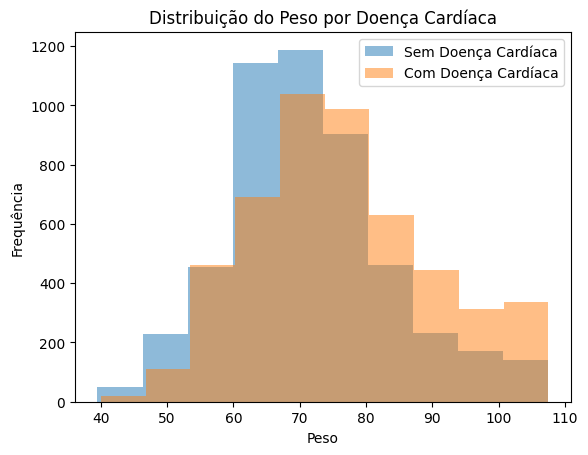

In [50]:
plt.figure()

plt.hist(cardio_0['weight'], alpha=0.5, label='Sem Doença Cardíaca')
plt.hist(cardio_1['weight'], alpha=0.5, label='Com Doença Cardíaca')

plt.title('Distribuição do Peso por Doença Cardíaca')
plt.xlabel('Peso')
plt.ylabel('Frequência')
plt.legend()

plt.show()

<Figure size 640x480 with 0 Axes>

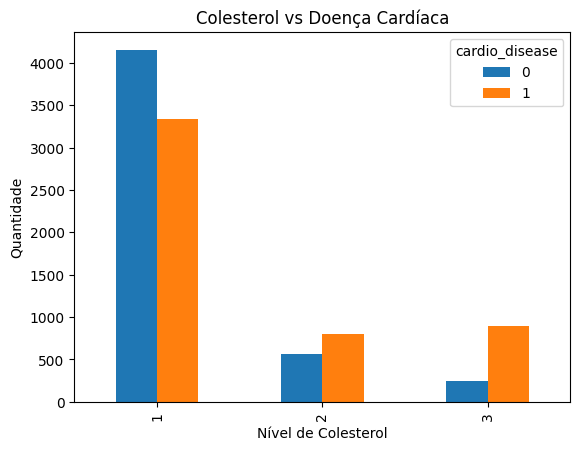

In [51]:
plt.figure()

# Contagem por categoria
pd.crosstab(
    base['cholesterol'],
    base['cardio_disease']
).plot(kind='bar')

plt.title('Colesterol vs Doença Cardíaca')
plt.xlabel('Nível de Colesterol')
plt.ylabel('Quantidade')

plt.show()

# **INSIGHTS**

---


- A análise bivariada entre a variável cardio_disease e as variáveis age, weight e cholesterol revelou padrões importantes associados ao desenvolvimento de doenças cardíacas.
- Observou-se que indivíduos com doença cardíaca apresentam maior concentração em faixas etárias mais elevadas, principalmente acima dos 50 anos, indicando que o avanço da idade pode aumentar o risco cardiovascular.
- Em relação ao peso corporal, nota-se que indivíduos com doença cardíaca tendem a se concentrar em faixas de peso mais altas, sugerindo que o excesso de peso pode estar associado ao aumento do risco de doenças cardiovasculares.
- Além disso, a análise dos níveis de colesterol mostrou que indivíduos com níveis mais elevados (níveis 2 e 3) apresentam maior frequência de casos de doença cardíaca quando comparados aos indivíduos com colesterol normal (nível 1).

---
                                                                              
  De forma geral, os resultados indicam que idade avançada, maior peso corporale níveis elevados de colesterol são fatores potencialmente associados ao aumento da ocorrência de doenças cardíacas.

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



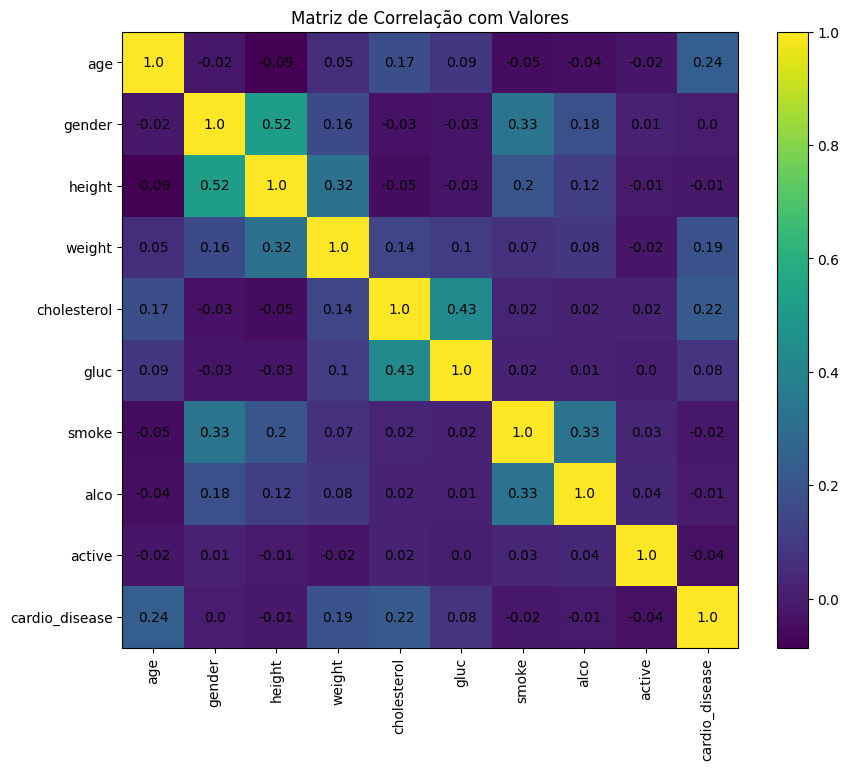

In [52]:
np

# Calculando matriz de correlação
correlacao = base.corr()

plt.figure(figsize=(10,8))

# Criando imagem da matriz
plt.imshow(correlacao)

plt.colorbar()

# Nome das colunas
plt.xticks(
    range(len(correlacao.columns)),
    correlacao.columns,
    rotation=90
)

plt.yticks(
    range(len(correlacao.columns)),
    correlacao.columns
)

# Adicionando os números dentro da matriz
for i in range(len(correlacao.columns)):
    for j in range(len(correlacao.columns)):
        plt.text(
            j,
            i,
            round(correlacao.iloc[i, j], 2),
            ha='center',
            va='center',
            color='black'
        )

plt.title('Matriz de Correlação com Valores')

plt.show()

# **INSIGHTS**

---


- A variável age apresentou correlação positiva com cardio_disease (0.24), indicando que o aumento da idade está associado a uma maior probabilidade de ocorrência de doença cardíaca. Esse resultado é coerente com o conhecimento clínico, uma vez que o risco cardiovascular tende a aumentar com o envelhecimento;
- Foi observada uma correlação moderada entre cholesterol e gluc (0.43), sugerindo que indivíduos com níveis elevados de colesterol tendem também a apresentar níveis mais altos de glicose. Essa relação pode indicar a presença de fatores metabólicos associados ao desenvolvimento de doenças cardiovasculares;
- A correlação positiva entre height e weight (0.32) indica que indivíduos mais altos tendem a apresentar maior peso corporal. Essa relação é esperada biologicamente e reforça a consistência dos dados analisados;
- Foi observada uma correlação moderada entre smoke e alco (0.33), indicando que indivíduos fumantes apresentam maior tendência ao consumo de álcool. Esse comportamento pode representar um padrão de hábitos de risco associados à saúde cardiovascular.
---
                                                                              
  A matriz de correlação foi utilizada para identificar relações entre as variáveis da base de dados. Observou-se que as variáveis age, cholesterol e weight apresentaram as maiores correlações positivas com a variável cardio_disease, indicando que idade avançada, níveis elevados de colesterol e maior peso corporal estão associados ao aumento do risco de doenças cardíacas. Além disso, foram identificadas correlações moderadas entre cholesterol e gluc, sugerindo associação entre fatores metabólicos, bem como entre height e weight, indicando coerência biológica dos dados. Também foi observada correlação entre smoke e alco, sugerindo que hábitos como tabagismo e consumo de álcool tendem a ocorrer simultaneamente. Essas relações contribuem para a compreensão dos fatores associados ao desenvolvimento de doenças cardiovasculares.

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [69]:
from sklearn.model_selection import train_test_split

# Separando variáveis independentes (x) e dependente (y)

x = base.drop('cardio_disease', axis=1)
y = base['cardio_disease']

# Separando treino e teste

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y   # mantém proporção das classes
)

print("Separação concluída.")

Separação concluída.


Considero necessário realizar a padronização dos dados nessa base, pois as variáveis apresentam escalas numéricas diferentes, como idade, altura e peso, que possuem valores significativamente maiores quando comparados a variáveis categóricas como colesterol e glicose. A padronização é importante porque evita que variáveis com valores mais altos tenham maior influência no modelo apenas por causa da sua escala. Além disso, essa etapa melhora o desempenho de diversos algoritmos de aprendizado de máquina, especialmente aqueles baseados em cálculo de distância ou otimização matemática, como regressão logística. Dessa forma, foi aplicada a técnica de padronização utilizando o método StandardScaler, que transforma os dados para que apresentem média igual a zero e desvio padrão igual a um, garantindo maior equilíbrio entre as variáveis durante o treinamento do modelo.

In [70]:
from sklearn.preprocessing import StandardScaler

# Criando o scaler
scaler = StandardScaler()

# Ajustando apenas nos dados de treino
X_train = scaler.fit_transform(x_train)

# Aplicando nos dados de teste
X_test = scaler.transform(x_test)

print("Padronização concluída.")

Padronização concluída.


In [71]:
import pandas as pd

print("Distribuição das classes:")
print(y.value_counts())

Distribuição das classes:
cardio_disease
1    5031
0    4969
Name: count, dtype: int64


In [77]:
print("Formato das bases:")

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# Visualizando alguns dados

print("\nPrimeiras linhas x_train:")
print(x_train[:5])

print("\nPrimeiros valores y_train:")
print(y_train[:5])

Formato das bases:
x_train: (7000, 9)
x_test: (3000, 9)
y_train: (7000,)
y_test: (3000,)

Primeiras linhas x_train:
       age  gender  height  weight  cholesterol  gluc  smoke  alco  active
5964  53.0       1   168.0    79.0            1     1      0     0       1
1774  64.0       1   163.0    69.0            3     3      0     0       1
5753  58.0       1   173.0    80.0            2     2      1     0       1
9265  62.0       2   162.0    67.0            1     1      1     0       1
7658  52.0       2   178.0    67.0            1     1      0     0       1

Primeiros valores y_train:
5964    0
1774    1
5753    1
9265    1
7658    0
Name: cardio_disease, dtype: int64


# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [78]:
from sklearn.linear_model import LogisticRegression

# Criando o modelo
modelo = LogisticRegression(max_iter=1000)

# Treinando o modelo
modelo.fit(x_train, y_train)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


In [79]:
import pandas as pd

# Intercepto
print("Intercepto:")
print(modelo.intercept_)

# Coeficientes
coeficientes = pd.DataFrame({
    'Variavel': x.columns,
    'Coeficiente': modelo.coef_[0]
})

# Ordenando coeficientes
coeficientes = coeficientes.sort_values(
    by='Coeficiente',
    ascending=False
)

print("\nCoeficientes:")
print(coeficientes)

Intercepto:
[-3.6845001]

Coeficientes:
      Variavel  Coeficiente
4  cholesterol     0.607349
0          age     0.063183
1       gender     0.032949
3       weight     0.029167
2       height    -0.014471
7         alco    -0.028130
6        smoke    -0.059736
5         gluc    -0.098561
8       active    -0.226067


In [80]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Previsões no treino
y_pred_train = modelo.predict(x_train)

print("Métricas no TREINO\n")

print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("Precision:", precision_score(y_train, y_pred_train))
print("Recall:", recall_score(y_train, y_pred_train))
print("F1-score:", f1_score(y_train, y_pred_train))

print("\nMatriz de Confusão (Treino):")
print(confusion_matrix(y_train, y_pred_train))

print("\nRelatório de Classificação (Treino):")
print(classification_report(y_train, y_pred_train))

Métricas no TREINO

Accuracy: 0.6375714285714286
Precision: 0.6481203007518797
Recall: 0.6118682566723452
F1-score: 0.6294727617934862

Matriz de Confusão (Treino):
[[2308 1170]
 [1367 2155]]

Relatório de Classificação (Treino):
              precision    recall  f1-score   support

           0       0.63      0.66      0.65      3478
           1       0.65      0.61      0.63      3522

    accuracy                           0.64      7000
   macro avg       0.64      0.64      0.64      7000
weighted avg       0.64      0.64      0.64      7000



Com base nas métricas obtidas, observa-se que o modelo apresentou desempenho satisfatório na realização das previsões. A **acurácia obtida foi de aproximadamente 64%**, indicando que o modelo conseguiu classificar corretamente uma parcela significativa dos dados. As métricas de precisão, recall e F1-score também apresentaram valores próximos entre si, demonstrando equilíbrio na identificação das classes. A matriz de confusão mostra que o modelo foi capaz de prever corretamente tanto casos positivos quanto negativos, indicando que a Regressão Logística se mostrou adequada para este problema, embora ainda existam possibilidades de melhoria futura.

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

In [81]:
# Previsões do modelo nos dados de teste
y_pred = modelo.predict(x_test)

print("Previsões realizadas com sucesso.")

Previsões realizadas com sucesso.


In [82]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Métricas no TESTE\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

Métricas no TESTE

Accuracy: 0.637
Precision: 0.6448275862068965
Recall: 0.6196156394963552
F1-score: 0.6319702602230484

Matriz de Confusão:
[[976 515]
 [574 935]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.63      0.65      0.64      1491
           1       0.64      0.62      0.63      1509

    accuracy                           0.64      3000
   macro avg       0.64      0.64      0.64      3000
weighted avg       0.64      0.64      0.64      3000



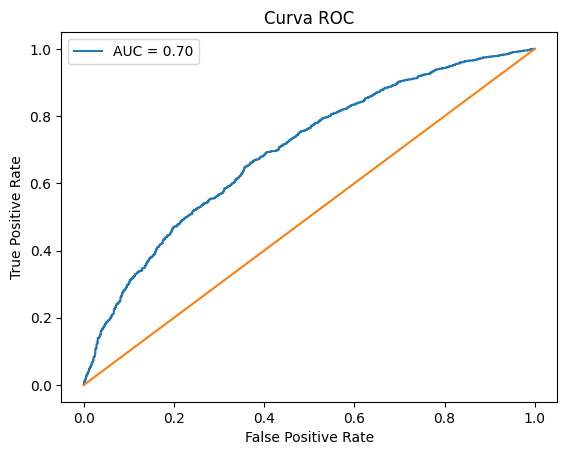

AUC: 0.6969522013903611


In [83]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# Probabilidade da classe positiva
y_prob = modelo.predict_proba(x_test)[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC
auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % auc)
plt.plot([0,1], [0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()

plt.show()

print("AUC:", auc)

A curva ROC foi utilizada para avaliar a capacidade do modelo em distinguir corretamente entre as classes positiva e negativa. No gráfico apresentado, observa-se que a curva está posicionada acima da linha diagonal, que representa uma classificação aleatória, indicando que o modelo possui capacidade de discriminação entre as classes. O **valor da AUC (Área Sob a Curva) obtido foi aproximadamente 0,70**, o que indica que **o modelo possui desempenho razoável na separação entre indivíduos com e sem doença cardíaca.** Dessa forma, conclui-se que o modelo apresenta capacidade satisfatória de classificação, sendo superior ao acaso e adequado para este tipo de análise, embora ainda possa ser aprimorado para alcançar resultados mais precisos

# 7) Explique:

A) Explique com suas palavras regressão logistica.

**Resposta**: A regressão logística é um algoritmo de aprendizado de máquina utilizado para prever a probabilidade de ocorrência de um determinado evento, geralmente representado por duas classes, como sim ou não, verdadeiro ou falso. Esse modelo utiliza uma função matemática chamada função logística (ou sigmoide), que transforma os resultados em valores entre 0 e 1, permitindo interpretar esses valores como probabilidades. Dessa forma, a regressão logística é amplamente utilizada em problemas onde se deseja prever a ocorrência de um evento, como a presença ou ausência de uma doença.

B) Explique porque a regressão logistica é um modelo de classificação.

**Resposta:** A regressão logística é considerada um modelo de classificação porque seu objetivo principal é atribuir observações a categorias ou classes específicas. Embora o modelo calcule probabilidades numéricas entre 0 e 1, essas probabilidades são utilizadas para decidir a qual classe o dado pertence, normalmente utilizando um limite de decisão, como 0,5. Assim, se a probabilidade prevista for maior que esse limite, o modelo classifica o registro como pertencente a uma determinada classe, e caso contrário, classifica na outra classe, caracterizando um processo típico de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.

**Resposta:** A regressão logística possui diversos pontos em comum com a regressão linear, pois ambas utilizam uma combinação linear das variáveis independentes para realizar previsões. Nos dois modelos, são utilizados coeficientes que representam o impacto de cada variável sobre o resultado final. Além disso, ambos utilizam técnicas de otimização matemática para ajustar os coeficientes e minimizar erros durante o treinamento. A principal diferença entre elas está no tipo de saída gerada, já que a regressão linear prevê valores contínuos, enquanto a regressão logística prevê probabilidades associadas a classes.

